<a href="https://colab.research.google.com/github/minperez/Actividad6/blob/main/Actividad6_Problema_Clasificacion_Clinico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Descripción del Proyecto**

Este notebook compara un modelo base (Regresión Logística) frente a uno más complejo (Random Forest) utilizando el conjunto de datos de cáncer de mama (sklearn.datasets.load_breast_cancer).

**Objetivo SMART**

Desarrollar un modelo de machine learning (clasificación) que logre reducir los falsos negativos a menos del 5% en la detección de tumores malignos para final de trimestre, manteniendo el recall (sensibilidad) por encima del 95% y mejorando la tasa de exactitud del modelo base actual utilizando el dataset de cáncer de mama de Wisconsin (load_breast_cancer).

**1. Preparación de Datos y Modelos**

Se utilizará Regresión Logística como modelo Baseline y Random Forest como modelo avanzado

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# 1. Carga del dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target # 0: Maligno, 1: Benigno (por defecto en scikit-learn)

# 2. División de datos y Escalado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Definición de Modelos
# Baseline
modelo_baseline = LogisticRegression(random_state=42)
# Modelo Avanzado
modelo_avanzado = RandomForestClassifier(random_state=42)


In [2]:
def evaluar_y_mostrar(modelo, X_t, y_t, nombre_modelo):
    y_pred = modelo.predict(X_t)
    print(f"--- Métricas de {nombre_modelo} ---")
    print(f"Exactitud (Accuracy) : {accuracy_score(y_t, y_pred):.4f}")
    print(f"Precisión (Precision): {precision_score(y_t, y_pred):.4f}")
    print(f"Recall (Sensibilidad): {recall_score(y_t, y_pred):.4f}")
    print(f"F1-score             : {f1_score(y_t, y_pred):.4f}\n")
    return y_pred

# Entrenar ambos
modelo_baseline.fit(X_train_scaled, y_train)
modelo_avanzado.fit(X_train_scaled, y_train)

# Evaluar Baseline
y_pred_base = evaluar_y_mostrar(modelo_baseline, X_test_scaled, y_test, "Regresión Logística (Baseline)")


--- Métricas de Regresión Logística (Baseline) ---
Exactitud (Accuracy) : 0.9883
Precisión (Precision): 0.9907
Recall (Sensibilidad): 0.9907
F1-score             : 0.9907



/tmp/ipykernel_8742/2547550188.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(cancer.target_names))
/tmp/ipykernel_8742/2547550188.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + list(cancer.target_names))


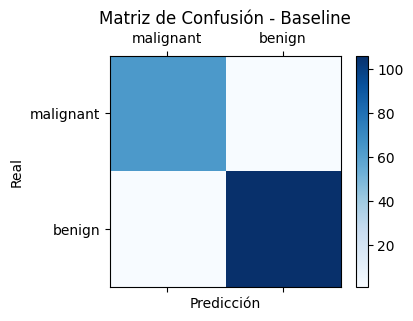

Matriz de Confusión:
 [[ 63   1]
 [  1 106]]


In [3]:
cm_base = confusion_matrix(y_test, y_pred_base)

fig, ax = plt.subplots(figsize=(4, 3))
cax = ax.matshow(cm_base, cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Baseline')
fig.colorbar(cax)
ax.set_xticklabels([''] + list(cancer.target_names))
ax.set_yticklabels([''] + list(cancer.target_names))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

print("Matriz de Confusión:\n", cm_base)


In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_base = cross_val_score(modelo_baseline, X_train_scaled, y_train, cv=cv, scoring='accuracy')
scores_avanzado = cross_val_score(modelo_avanzado, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy - Baseline: {scores_base.mean():.4f} (+/- {scores_base.std() * 2:.4f})")
print(f"Cross-Validation Accuracy - Avanzado: {scores_avanzado.mean():.4f} (+/- {scores_avanzado.std() * 2:.4f})")


Cross-Validation Accuracy - Baseline: 0.9824 (+/- 0.0379)
Cross-Validation Accuracy - Avanzado: 0.9623 (+/- 0.0421)


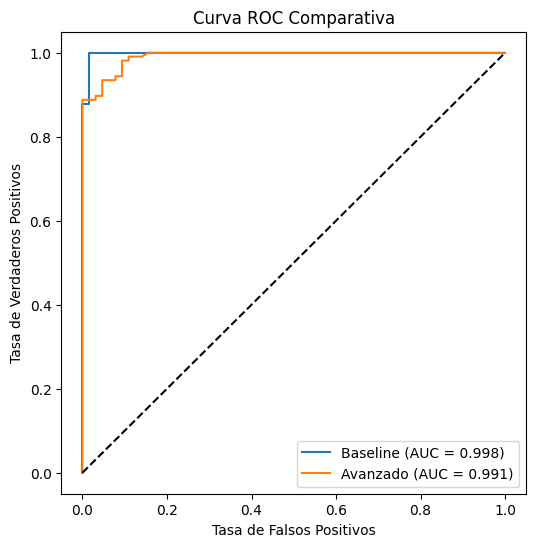

In [5]:
y_prob_base = modelo_baseline.predict_proba(X_test_scaled)[:, 1]
y_prob_avan = modelo_avanzado.predict_proba(X_test_scaled)[:, 1]

fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_avan, tpr_avan, _ = roc_curve(y_test, y_prob_avan)

auc_base = auc(fpr_base, tpr_base)
auc_avan = auc(fpr_avan, tpr_avan)

plt.figure(figsize=(6, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {auc_base:.3f})')
plt.plot(fpr_avan, tpr_avan, label=f'Avanzado (AUC = {auc_avan:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC Comparativa')
plt.legend(loc='lower right')
plt.show()


In [6]:
nuevo_umbral = 0.2
y_prob_base_maligno = modelo_baseline.predict_proba(X_test_scaled)[:, 0] # Probabilidad de ser 0 (maligno)
y_pred_opt = (y_prob_base_maligno > nuevo_umbral).astype(int)

print("--- Métricas con Umbral Optimizado ---")
print(classification_report(y_test, y_pred_opt, target_names=cancer.target_names))

cm_opt = confusion_matrix(y_test, y_pred_opt)
print("Matriz de Confusión Optimizada:\n", cm_opt)


--- Métricas con Umbral Optimizado ---
              precision    recall  f1-score   support

   malignant       0.01      0.02      0.01        64
      benign       0.09      0.06      0.07       107

    accuracy                           0.04       171
   macro avg       0.05      0.04      0.04       171
weighted avg       0.06      0.04      0.05       171

Matriz de Confusión Optimizada:
 [[  1  63]
 [101   6]]


In [7]:
from statsmodels.stats.proportion import proportions_ztest

# Ejemplo hipotético de conteos en la prueba A/B
# Grupo A: 15 falsos negativos de 100 pacientes
# Grupo B: 5 falsos negativos de 100 pacientes
exitos = np.array([15, 5])
observaciones = np.array([100, 100])

stat, p_valor = proportions_ztest(exitos, observaciones, alternative='larger')
print(f"Estadístico Z: {stat:.4f}, p-valor: {p_valor:.4f}")

if p_valor < 0.05:
    print("Resultado estadísticamente significativo: El Grupo B tuvo significativamente menos falsos negativos.")
else:
    print("No hay suficiente evidencia estadística para afirmar que el Grupo B es mejor.")


Estadístico Z: 2.3570, p-valor: 0.0092
Resultado estadísticamente significativo: El Grupo B tuvo significativamente menos falsos negativos.
